In [ ]:
!pip install pandas matplotlib seaborn openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


caminho_arquivo = 'Tabela_13_Meio_de_transporte.xlsx'
df_exemplo = pd.read_excel(caminho_arquivo, sheet_name='Exemplo gráfico Brasil', header=1)

df_exemplo.rename(columns={
    'Meio de transporte/cor ou raça': 'Meio de Transporte',
    'Preta ou parda': 'Preta ou Parda'
}, inplace=True)

df_exemplo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


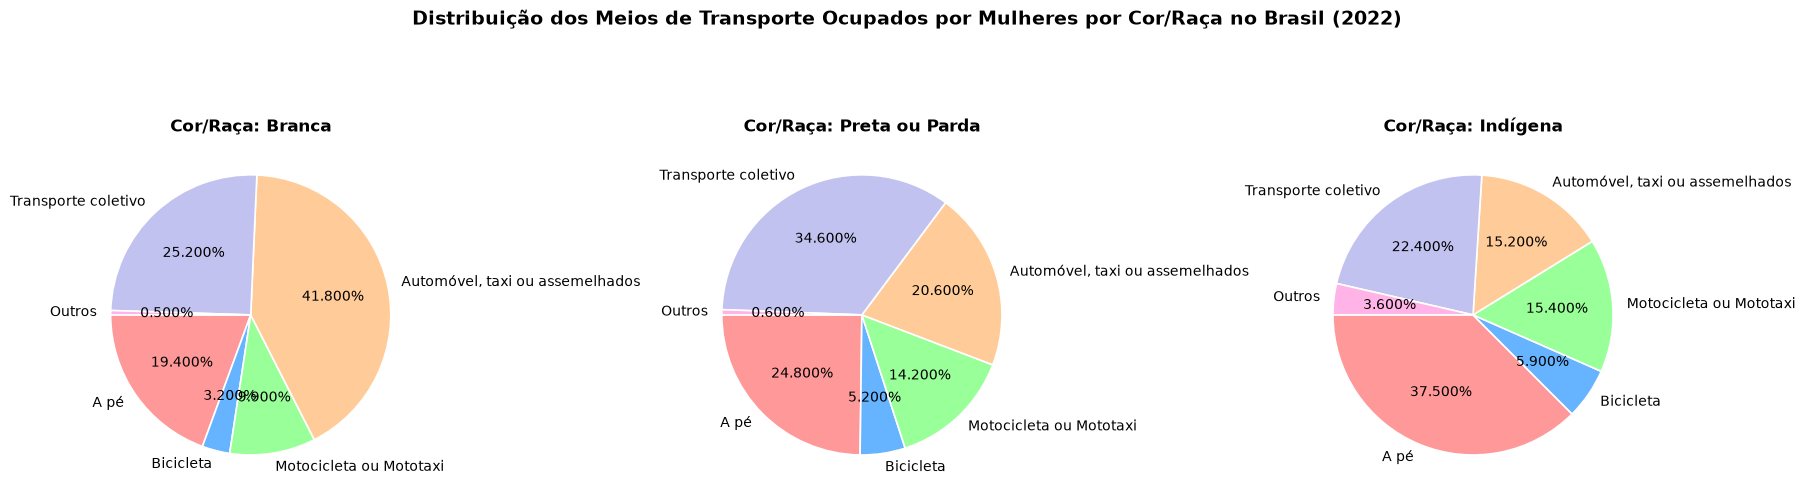

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df_exemplo[col],
        labels=df_exemplo['Meio de Transporte'],
        autopct='%1.3f%%',  
        startangle=180,     
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Distribuição dos Meios de Transporte Ocupados por Mulheres por Cor/Raça no Brasil (2022)',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [ ]:
df_br_raw = pd.read_excel(caminho_arquivo, sheet_name='BR GR UF MU', header=[0, 1])

col_names = ['Localidade']

for c in df_br_raw.columns[1:]:
    raca = str(c[0]).strip()
    meio = str(c[1]).strip()
    col_names.append(f"{raca}__{meio}")

df_br = df_br_raw.copy()
df_br.columns = col_names
df_br = df_br.dropna(subset=['Localidade'])
df_br['Localidade'] = df_br['Localidade'].astype(str).str.strip()

estados_br = [
    'Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá', 'Tocantins',
    'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte', 'Paraíba', 'Pernambuco',
    'Alagoas', 'Sergipe', 'Bahia', 'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro',
    'São Paulo', 'Paraná', 'Santa Catarina', 'Rio Grande do Sul',
    'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal'
]

value_cols = [c for c in df_br.columns if c != 'Localidade']
for c in value_cols:
    df_br[c] = pd.to_numeric(df_br[c], errors='coerce')

df_estados = df_br[df_br['Localidade'].isin(estados_br)].copy()
print('Lista dos Estados:')
print(df_estados['Localidade'].tolist())

df_melted = df_br.melt(id_vars=['Localidade'], var_name='Grupo_Meio', value_name='Percentual')
df_melted[['Cor_Raca', 'Meio_Transporte']] = df_melted['Grupo_Meio'].str.split('__', expand=True)
df_melted.drop(columns=['Grupo_Meio'], inplace=True)

df_melted.head(10)

Lista dos Estados:
['Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá', 'Tocantins', 'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte', 'Paraíba', 'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia', 'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo', 'Paraná', 'Santa Catarina', 'Rio Grande do Sul', 'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal']


,Localidade,Percentual,Cor_Raca,Meio_Transporte
0,Brasil,19.4,Tabela 13 - Distribuição percentual das mulher...,Branca
1,Norte,15.2,Tabela 13 - Distribuição percentual das mulher...,Branca
2,Nordeste,24.9,Tabela 13 - Distribuição percentual das mulher...,Branca
3,Sudeste,18.5,Tabela 13 - Distribuição percentual das mulher...,Branca
4,Sul,20.8,Tabela 13 - Distribuição percentual das mulher...,Branca
5,Centro-oeste,12.3,Tabela 13 - Distribuição percentual das mulher...,Branca
6,Rondônia,11.7,Tabela 13 - Distribuição percentual das mulher...,Branca
7,Acre,14.8,Tabela 13 - Distribuição percentual das mulher...,Branca
8,Amazonas,13.9,Tabela 13 - Distribuição percentual das mulher...,Branca
9,Roraima,11.6,Tabela 13 - Distribuição percentual das mulher...,Branca
